# What can these music datasets tell us?
## Initial EDA · Billboard and audio features

**Purpose:** understand the raw files before deciding how to clean, join, and engineer features.

**Working questions:** How have the audio characteristics of charting songs changed over time? How do audio characteristics impact chart performance?

**Notes:** This notebook contains some assistance from ChatGPT in the form of generated code and points of analysis

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('../data/raw')

billboard = pd.read_csv(DATA_DIR / 'billboard.csv')
audio = pd.read_csv(DATA_DIR / 'audio_features.csv')
display(pd.DataFrame({'rows': [len(billboard), len(audio)],
                      'columns': [billboard.shape[1], audio.shape[1]]},
                     index=['Billboard', 'Audio']))
display(billboard.head(3))
display(audio.head(3).drop(columns=['spotify_track_preview_url']))

,rows,columns
Billboard,327895,10
Audio,29503,22


,url,week_id,week_position,song,performer,song_id,instance,previous_week_position,peak_position,weeks_on_chart
0,http://www.billboard.com/charts/hot-100/1965-0...,7/17/1965,34,Don't Just Stand There,Patty Duke,Don't Just Stand TherePatty Duke,1,45.0,34,4
1,http://www.billboard.com/charts/hot-100/1965-0...,7/24/1965,22,Don't Just Stand There,Patty Duke,Don't Just Stand TherePatty Duke,1,34.0,22,5
2,http://www.billboard.com/charts/hot-100/1965-0...,7/31/1965,14,Don't Just Stand There,Patty Duke,Don't Just Stand TherePatty Duke,1,22.0,14,6


,song_id,performer,song,spotify_genre,spotify_track_id,spotify_track_duration_ms,spotify_track_explicit,spotify_track_album,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity
0,-twistin'-White Silver SandsBill Black's Combo,Bill Black's Combo,-twistin'-White Silver Sands,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,¿Dònde Està Santa Claus? (Where Is Santa Claus...,Augie Rios,¿Dònde Està Santa Claus? (Where Is Santa Claus?),['novelty'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,......And Roses And RosesAndy Williams,Andy Williams,......And Roses And Roses,"['adult standards', 'brill building pop', 'eas...",3tvqPPpXyIgKrm4PR9HCf0,166106.0,False,The Essential Andy Williams,0.154,0.185,5.0,-14.063,1.0,0.0315,0.911,0.000267,0.112,0.15,83.969,4.0,38.0


## 1. What does one row represent?
**Why:** counting rows as songs would overweight songs that remain on the chart longer. We also need to distinguish numerical measurements from identifiers and categories.

Billboard appears to contain one song's position in one chart week. The audio file is intended to describe songs, but we must test whether it has one row per song. `song_id` is a text-based identifier shared by the files, not a Spotify track ID.

Useful column groups:

| Group | Columns | Interpretation / caution |
|---|---|---|
| Identity | `song_id`, `song`, `performer` | Check uniqueness before joining. |
| Weekly chart | `week_id`, `week_position` | Date and rank; a smaller rank is better. |
| Chart history | `previous_week_position`, `peak_position`, `weeks_on_chart`, `instance` | Verify source definitions, especially re-entries and chart runs. |
| Audio descriptors | `danceability`, `energy`, `valence`, `acousticness`, etc. | Algorithmic descriptors, not direct measures of human emotion or quality. |
| Other measurements | `tempo`, `loudness`, `spotify_track_duration_ms` | Different units; do not compare raw magnitudes. |
| Encoded categories | `key`, `mode`, `time_signature` | Numeric storage does not make them continuous measurements. |
| Spotify metadata | `spotify_genre`, `spotify_track_popularity`, album, explicit flag | Genre is list-like; popularity is not historical weekly Billboard popularity. |


### Duplicates and Missing Data

In [3]:
for name, df in [('Billboard', billboard), ('Audio', audio)]:
    print(name)
    display(pd.DataFrame({'dtype': df.dtypes.astype(str),
                          'missing_pct': df.isna().mean().mul(100).round(2),
                          'distinct_nonmissing': df.nunique()}))
    print('Exact duplicate rows:', df.duplicated().sum())
    print('Distinct song IDs:', df.song_id.nunique())

print('Additional audio rows beyond one per song ID:', audio.song_id.duplicated().sum())
display(audio.loc[audio.song_id.duplicated(keep=False),
                  ['song_id', 'spotify_track_id', 'energy', 'spotify_track_popularity']].head(10))

Billboard


,dtype,missing_pct,distinct_nonmissing
url,object,0.00,3279
week_id,object,0.00,3279
week_position,int64,0.00,100
song,object,0.00,24360
performer,object,0.00,10061
song_id,object,0.00,29389
instance,int64,0.00,10
previous_week_position,float64,9.75,100
peak_position,int64,0.00,100
weeks_on_chart,int64,0.00,87


Exact duplicate rows: 0
Distinct song IDs: 29389
Audio


,dtype,missing_pct,distinct_nonmissing
song_id,object,0.00,29386
performer,object,0.00,10059
song,object,0.00,24359
spotify_genre,object,5.42,3375
spotify_track_id,object,17.31,24177
spotify_track_preview_url,object,50.88,14371
spotify_track_duration_ms,float64,17.31,13984
spotify_track_explicit,object,17.31,2
spotify_track_album,object,17.33,13125
danceability,float64,17.52,837


Exact duplicate rows: 24
Distinct song IDs: 29386
Additional audio rows beyond one per song ID: 117


,song_id,spotify_track_id,energy,spotify_track_popularity
344,24/7Meek Mill Featuring Ella Mai,NaN,NaN,NaN
345,24/7Meek Mill Featuring Ella Mai,NaN,NaN,NaN
540,A Holly Jolly ChristmasBurl Ives,65Q2mv3UlVi9eO70OpsmSe,0.375,80.0
541,A Holly Jolly ChristmasBurl Ives,65Q2mv3UlVi9eO70OpsmSe,0.370,82.0
803,Act UpCity Girls,3A2yGHWIzmGEIolwonU69h,0.638,79.0
804,Act UpCity Girls,3A2yGHWIzmGEIolwonU69h,0.638,80.0
1108,All I Want For Christmas Is YouMariah Carey,0bYg9bo50gSsH3LtXe2SQn,0.625,95.0
1109,All I Want For Christmas Is YouMariah Carey,0bYg9bo50gSsH3LtXe2SQn,0.625,97.0
1196,All The Good Girls Go To HellBillie Eilish,6IRdLKIyS4p7XNiP8r6rsx,0.444,86.0
1197,All The Good Girls Go To HellBillie Eilish,6IRdLKIyS4p7XNiP8r6rsx,0.444,87.0


**What we found:** Billboard has 327,895 rows for 29,389 song IDs. Audio has 29,503 rows for 29,386 song IDs, including 24 exact duplicate rows and 117 extra rows beyond one per song ID. Some repeated IDs disagree on measurements or metadata.

**Decision:** do not merge the raw tables immediately or arbitrarily keep the first audio row. Exact duplicates and conflicting records need different rules. For exploratory audio plots below, exclude *all* repeated audio IDs as a conservative temporary choice; this is not the final cleaning policy.


## 2. Is the chart history complete and internally consistent?
**Why:** missing weeks, duplicated positions, and partial years could create misleading changes over time. A chart can have 100 rows and still have duplicate positions.


Unparseable dates: 0
Date range: 1958-08-02 to 2021-05-29
Missing dates in the seven-day sequence: 0
Weeks with other than 100 rows:


,rows
date,
1991-11-16,99
1991-11-23,99
1991-11-30,99
1991-12-07,99
1991-12-14,99


Extra rows sharing a week and rank: 29
Extra rows sharing a week and song: 13
Ranks outside 1–100: 0
Peak worse than current rank: 0


,week_id,week_position,song,performer
1302,8/26/1961,69,One Track Mind,Bobby Lewis
4464,8/2/1958,63,Padre,Toni Arden
4873,2/18/1984,67,Remember The Nights,The Motels
6112,8/2/1958,50,By The Light Of The Silvery Moon,Jimmy Bowen with the Rhythm Orchids
6113,8/2/1958,50,"Baubles, Bangles And Beads",The Kirby Stone Four
18553,8/2/1958,63,High School Confidential,Jerry Lee Lewis And His Pumping Piano
19328,8/16/1958,71,Lazy Summer Night,The Four Preps
19768,8/2/1958,74,Gotta Have Rain,Eydie Gorme
28409,2/4/1978,58,Sweet Music Man,Kenny Rogers
37286,8/16/1958,5,Patricia,Perez Prado And His Orchestra


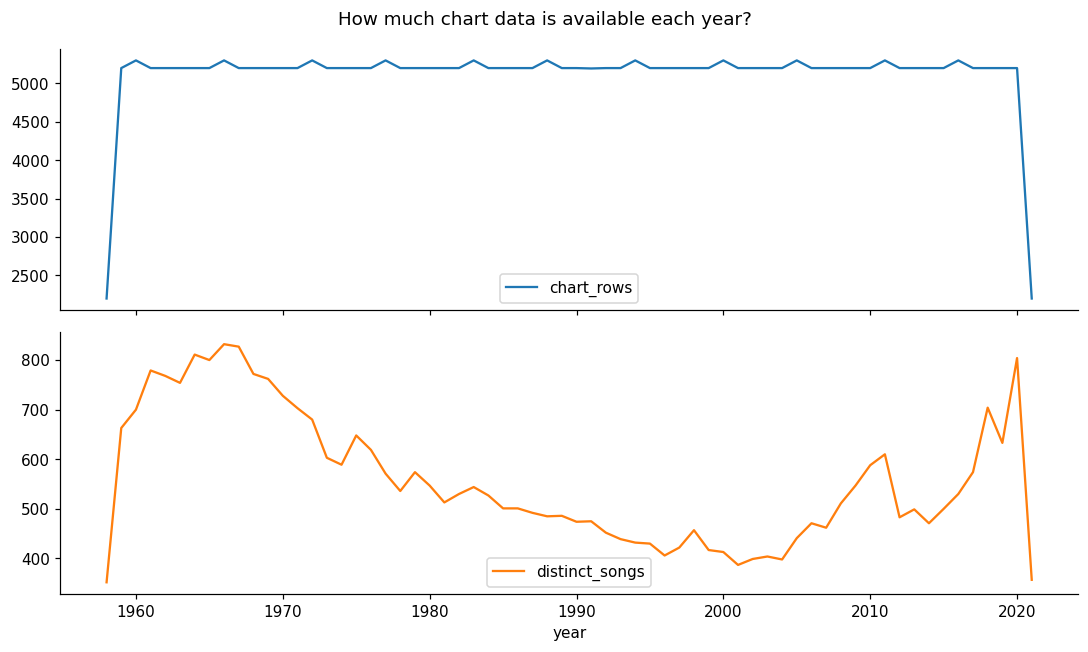

,chart_rows,distinct_songs,weeks
year,,,
1958,2200,352,22
2021,2200,357,22


In [5]:
# Parse into a separate Series; leave the source column untouched.
chart_dates = pd.to_datetime(billboard.week_id, format='%m/%d/%Y', errors='coerce')
print('Unparseable dates:', chart_dates.isna().sum())
print('Date range:', chart_dates.min().date(), 'to', chart_dates.max().date())
week_sizes = billboard.assign(date=chart_dates).groupby('date').size().sort_index()
expected_weeks = pd.date_range(week_sizes.index.min(), week_sizes.index.max(), freq='7D')
print('Missing dates in the seven-day sequence:', len(expected_weeks.difference(week_sizes.index)))
print('Weeks with other than 100 rows:')
display(week_sizes[week_sizes != 100].rename('rows').to_frame())
print('Extra rows sharing a week and rank:', billboard.duplicated(['week_id', 'week_position']).sum())
print('Extra rows sharing a week and song:', billboard.duplicated(['week_id', 'song_id']).sum())
print('Ranks outside 1–100:', (~billboard.week_position.between(1, 100)).sum())
print('Peak worse than current rank:', (billboard.peak_position > billboard.week_position).sum())
display(billboard.loc[billboard.duplicated(['week_id', 'week_position'], keep=False),
                      ['week_id', 'week_position', 'song', 'performer']].head(10))
year_counts = billboard.assign(year=chart_dates.dt.year).groupby('year').agg(
    chart_rows=('song_id', 'size'), distinct_songs=('song_id', 'nunique'), weeks=('week_id', 'nunique'))
year_counts[['chart_rows', 'distinct_songs']].plot(subplots=True, figsize=(10, 6))
plt.suptitle('How much chart data is available each year?')
plt.tight_layout()
plt.show()
display(year_counts.iloc[[0, -1]])

**What we found:** the chart spans August 2, 1958–May 29, 2021. Both boundary years are partial. Five weeks contain 99 rows; there are also 29 extra rows sharing a week/rank and 13 sharing a week/song.

**Decision:** inspect the conflicting chart records against the source before deduplication. Start annual comparisons with 1959–2020, then assess any remaining anomalies. A low count in 1958 and 2021 is expected and should not be treated as anomalies. Repeated song appearances in different weeks are expected. Ideally we would like to analyze songs up to today, but Spotify's audio features API was deprecated 11/2024. Depending on our findings, we may decide to pull data from other sources to fill in between 5/2021 and 11/2024.


## 3. Which information is missing—and what counts as missing?
**Why:** dropping every row with any missing value would discard useful songs just because a preview URL is absent. Missing genres may also be stored as `[]`, which pandas does not count as null.


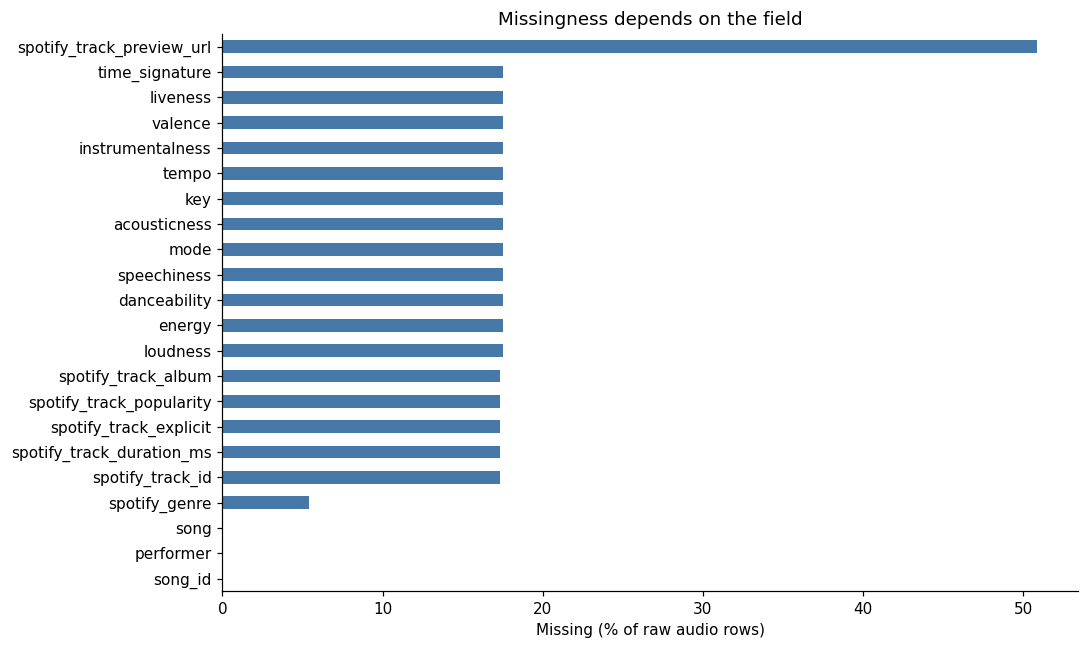

,song,week_id,instance,weeks_on_chart
8,Don't Keep Wasting My Time,4/19/1997,1,1
14,Don't Knock My Love - Pt. 1,4/24/1971,1,1
26,Don't Knock My Love,7/13/1974,1,1
35,Don't Know Much,3/28/1981,1,1
39,Don't Know Much,9/30/1989,1,1
65,Don't Know What You Got (Till It's Gone),9/3/1988,1,1
87,Don't Know Why,9/28/2002,1,1
118,Don't Laugh At Me,12/5/1998,1,1


Null genre values: 1600
Empty genre lists: 2557
Missing previous-week position: 31954


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
audio.isna().mean().mul(100).sort_values().plot.barh(ax=ax, color='#4779a8')
ax.set(xlabel='Missing (% of raw audio rows)', title='Missingness depends on the field')
plt.tight_layout()
plt.show()
print('Null genre values:', audio.spotify_genre.isna().sum())
print('Empty genre lists:', audio.spotify_genre.fillna('').str.strip().eq('[]').sum())
print('Missing previous-week position:', billboard.previous_week_position.isna().sum())
display(billboard.loc[billboard.previous_week_position.isna(),
                      ['song', 'week_id', 'instance', 'weeks_on_chart']].head(8))

**Interpretation:** about 17.5% of raw audio rows lack audio measurements, while about half lack a preview URL. These have very different implications. Missing previous-week position could reflect entry or re-entry, not a corrupt record; the examples alone cannot establish its meaning.

**Decision:** define missingness rules for the columns required by each question. Do not fill missing audio with zero: zero is a real value for several descriptors. Keep missingness flags to study selection bias. Treat empty genre lists as unavailable information, and verify genre provenance before using the labels as song-level genres.


## 4. Can we join the files safely, and who would be left out?
**Why:** a matching song ID does not guarantee usable audio. Multiple audio rows per ID would multiply weekly chart entries in a merge. Coverage by time is especially important for our historical analysis.

For this diagnostic, we use only audio IDs appearing exactly once. Repeated IDs remain marked for review. Each coverage percentage below counts **distinct chart song IDs**, not chart appearances.


Chart songs without any exact audio ID match: 6


,song_id
5537,Do Re Miblackbear
6697,Everybody Dies In Their NightmaresXXXTENTACION
6787,Everything I WantedBillie Eilish
6874,F**k LoveXXXTENTACION Featuring Trippie Redd
13261,Jocelyn FloresXXXTENTACION
13903,La Noche de AnocheBad Bunny & Rosalia


Chart songs set aside because audio IDs repeat: 117


,songs,exact_match_pct,usable_core_pct
decade,,,
1950,925,100.0,65.3
1960,6850,100.0,76.2
1970,5299,100.0,79.4
1980,4113,100.0,85.2
1990,3423,100.0,81.9
2000,3418,100.0,91.3
2010,4446,99.9,91.6
2020,915,99.8,63.2


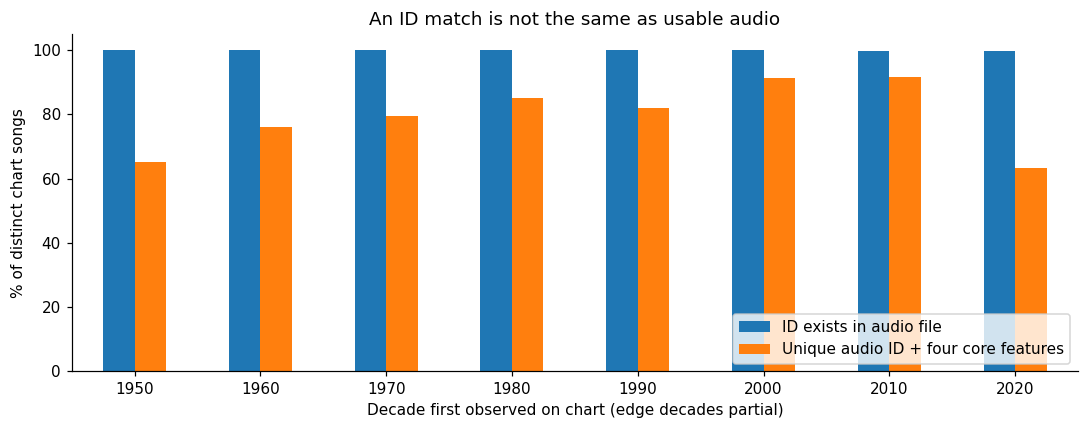

,songs,usable_core_pct
rank_group,,
Top 10,4982,89.2
11–40,8211,85.9
41–100,16196,77.9


In [6]:
core = ['danceability', 'energy', 'valence', 'acousticness']
repeated_ids = set(audio.loc[audio.song_id.duplicated(keep=False), 'song_id'])
audio_unique = audio.loc[~audio.song_id.duplicated(keep=False)].copy()

# A temporary one-song summary; first_seen is not necessarily the release date.
songs = billboard.assign(date=chart_dates).groupby('song_id').agg(
    first_seen=('date', 'min'), best_observed_rank=('week_position', 'min'),
    observed_chart_weeks=('date', 'nunique')).reset_index()
songs['first_year'] = songs.first_seen.dt.year
songs['decade'] = (songs.first_year // 10 * 10).astype('Int64')
songs['in_audio_file'] = songs.song_id.isin(audio.song_id)
songs['repeated_audio_id'] = songs.song_id.isin(repeated_ids)
joined = songs.merge(audio_unique[['song_id'] + core + ['tempo', 'loudness', 'spotify_track_duration_ms']],
                     on='song_id', how='left', validate='one_to_one')
joined['usable_core'] = joined[core].notna().all(axis=1)
print('Chart songs without any exact audio ID match:', (~songs.in_audio_file).sum())
display(songs.loc[~songs.in_audio_file, ['song_id']])
print('Chart songs set aside because audio IDs repeat:', songs.repeated_audio_id.sum())
coverage = joined.groupby('decade').agg(songs=('song_id', 'size'),
    exact_match_pct=('in_audio_file', 'mean'), usable_core_pct=('usable_core', 'mean'))
coverage[['exact_match_pct', 'usable_core_pct']] *= 100
display(coverage.round(1))
coverage[['exact_match_pct', 'usable_core_pct']].plot.bar(ylim=(0, 105), rot=0)
plt.ylabel('% of distinct chart songs')
plt.xlabel('Decade first observed on chart (edge decades partial)')
plt.title('An ID match is not the same as usable audio')
plt.legend(['ID exists in audio file', 'Unique audio ID + four core features'], loc='lower right')
plt.tight_layout()
plt.show()

joined['rank_group'] = pd.cut(joined.best_observed_rank, [0, 10, 40, 100], labels=['Top 10', '11–40', '41–100'])
display(joined.groupby('rank_group', observed=True).agg(
    songs=('song_id', 'size'), usable_core_pct=('usable_core', lambda x: 100*x.mean())).round(1))

**How to interpret:** compare the match and usable-audio columns. Only six chart song IDs lack an exact ID match, so attempting to match is not the first priority. The larger problem is missing audio and repeated records. The decade and rank-group tables test whether the songs we can study differ in time or chart success.

**Observed coverage:** usable core audio is available for 76.2% of songs first seen in the 1960s, compared with 91.6% in the 2010s. Coverage is only 63.2% for the partial 2020–2021 group. This makes missingness by era a concrete concern, especially for a recent-years comparison; it does not tell us why those records are missing.

**Decision:** preserve the full chart population with a left join and a coverage report. Resolve repeated audio IDs before merge, then use `validate='many_to_one'` for weekly rows. Report both song-level and chart-appearance coverage in our final analysis. Coverage differences are selection warnings; similar coverage would still not prove the missing songs are representative.

## 5. Are the values plausible, and what do their distributions look like?
**Why:** distributions help distinguish real extremes, skew, encoded categories, and possible data errors. We inspect unique-ID audio records to avoid giving duplicate records extra weight.

The ranges below are provisional checks based on the column meanings. Verify them against the original data dictionary before turning them into cleaning rules. Unusual tempo or loudness alone is not a reason to remove a song.


,rows flagged
danceability,0
energy,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0
valence,0
nonpositive duration,0
nonpositive tempo,1
key outside integer 0–11 or -1,0


,danceability,energy,valence,acousticness,tempo,loudness,spotify_track_duration_ms,instrumentalness
count,24116.000,24116.000,24116.000,24116.000,24116.000,24116.000,24179.000,24116.000
mean,0.599,0.618,0.602,0.295,120.290,-8.686,220903.257,0.033
std,0.153,0.199,0.239,0.283,28.018,3.602,67907.983,0.137
min,0.000,0.001,0.000,0.000,0.000,-28.030,29688.000,0.000
25%,0.498,0.475,0.415,0.046,99.120,-11.057,175066.000,0.000
50%,0.607,0.634,0.623,0.195,118.932,-8.238,215140.000,0.000
75%,0.707,0.777,0.802,0.509,136.445,-5.876,253573.000,0.000
max,0.988,0.997,0.991,0.991,241.009,2.291,3079157.000,0.982


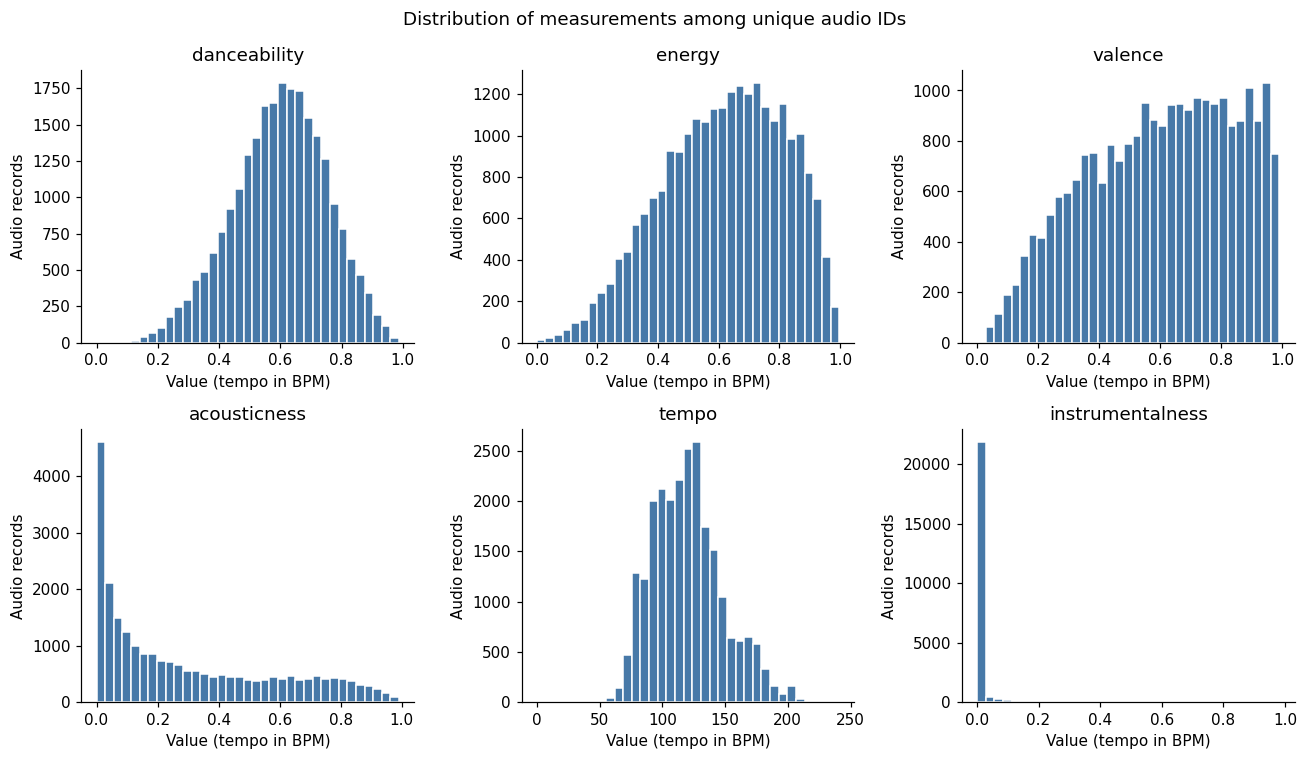

,song,performer,spotify_track_duration_ms
21033,Sexual,Goddess,3079157.0
26259,Tubular Bells,Mike Oldfield,1561133.0
1826,Autobahn,Kraftwerk,1367093.0
3506,By The Time I Get To Phoenix,Isaac Hayes,1124153.0
15570,Love To Love You Baby,Donna Summer,1008533.0


In [ ]:
bounded = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']
checks = {c: ((audio[c] < 0) | (audio[c] > 1)).sum() for c in bounded}
checks['nonpositive duration'] = (audio.spotify_track_duration_ms.dropna() <= 0).sum()
checks['nonpositive tempo'] = (audio.tempo.dropna() <= 0).sum()
checks['key outside integer 0–11 or -1'] = (~audio.key.dropna().isin(range(-1, 12))).sum()
checks['mode outside 0/1'] = (~audio['mode'].dropna().isin([0, 1])).sum()
display(pd.Series(checks, name='rows flagged').to_frame())
cols = core + ['tempo', 'loudness', 'spotify_track_duration_ms', 'instrumentalness']
display(audio_unique[cols].describe().round(3))
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.flat, core + ['tempo', 'instrumentalness']):
    ax.hist(audio_unique[col].dropna(), bins=35, color='#4779a8', edgecolor='white')
    ax.set(title=col, xlabel='Value (tempo in BPM)', ylabel='Audio records')
fig.suptitle('Distribution of measurements among unique audio IDs')
plt.tight_layout()
plt.show()
display(audio_unique.nlargest(5, 'spotify_track_duration_ms')[
    ['song', 'performer', 'spotify_track_duration_ms']])

**How to interpret:** instrumentalness is concentrated near zero, so its mean alone is not a good description of a typical song. The duration examples provide a small manual-review list, not an automatic deletion list. A value passing a range check can still belong to the wrong recording.

**Decision:** keep valid extremes, investigate suspicious values and track versions, and use medians or distribution plots for skewed measurements. Later, duration in minutes may improve readability. Avoid standardizing every column or binning tempo before choosing an analysis that needs it.


## 6. Do the audio descriptors overlap?
**Why:** correlated descriptors may tell similar stories. This helps us choose a small set of interpretable measures instead of presenting many redundant charts.

This is a descriptive correlation matrix of unique audio records with all six selected measurements.


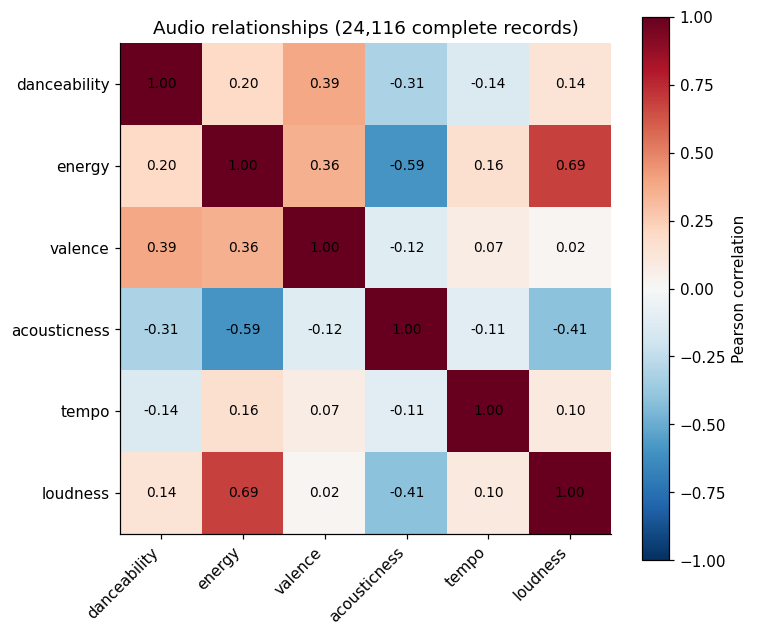

In [ ]:
corr_cols = core + ['tempo', 'loudness']
corr_data = audio_unique[corr_cols].dropna()
corr = corr_data.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title(f'Audio relationships ({len(corr_data):,} complete records)')
plt.tight_layout()
plt.show()


**Interpretation:** use the coefficients to identify overlap, particularly between energy, loudness, and acousticness. A pooled correlation can mix changes across eras with differences within an era. A high correlation does not make two concepts identical.

**Decision:** start with a few descriptors audio features that are relevant to our investigation. If a relationship seems important, examine it within eras and with a scatterplot before making a stronger claim.


## 7. Is there a promising historical story?
**Why:** an initial trend plot can suggest where to investigate next. We assign each song to the year it first appears in this file and count it once. That answers a different question from averaging every chart appearance, which gives long-running songs more weight.

For this view, we use 1959–2020 and require a unique audio ID with all four core audio features. Shading shows the middle 50% of song values.


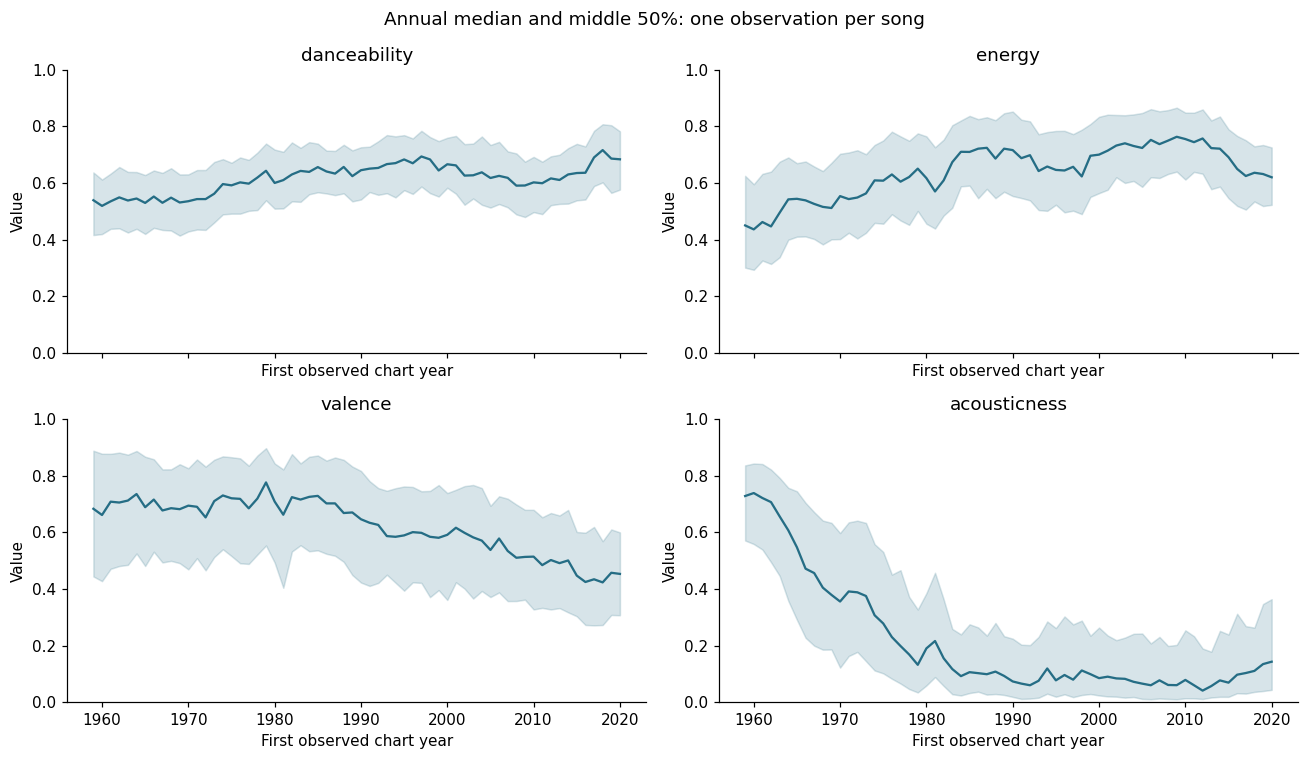

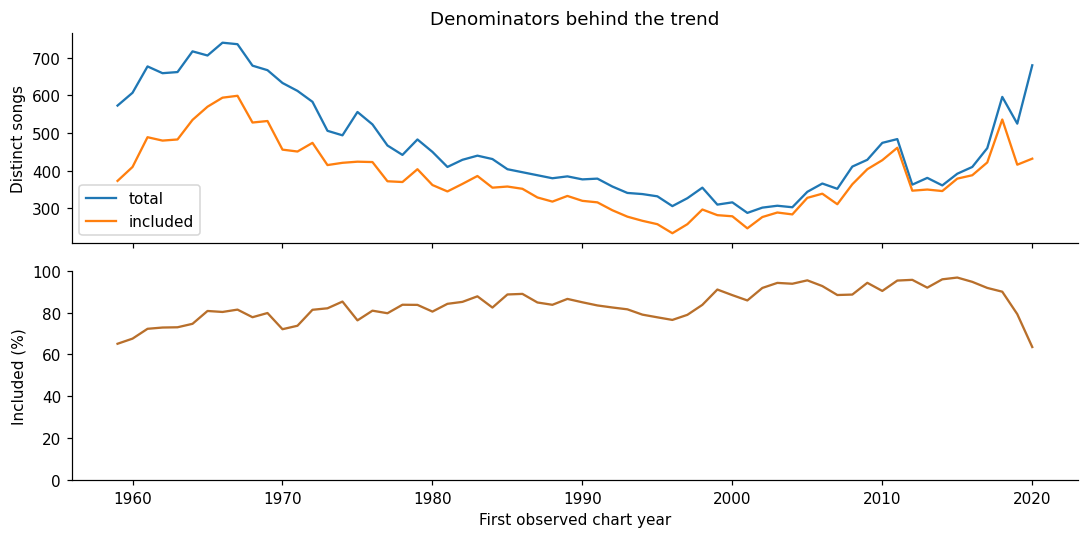

,danceability,energy,valence,acousticness
decade,,,,
1950,0.539,0.450,0.683,0.728
1960,0.538,0.510,0.696,0.579
1970,0.581,0.592,0.708,0.282
1980,0.634,0.675,0.703,0.125
1990,0.662,0.666,0.602,0.082
2000,0.623,0.738,0.558,0.072
2010,0.640,0.691,0.464,0.082
2020,0.684,0.620,0.453,0.143


In [ ]:
trend_sample = joined.loc[joined.first_year.between(1959, 2020) & joined.usable_core]
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, col in zip(axes.flat, core):
    g = trend_sample.groupby('first_year')[col]
    median, lower, upper = g.median(), g.quantile(.25), g.quantile(.75)
    ax.plot(median.index, median.values, color='#256d85')
    ax.fill_between(lower.index.to_numpy(), lower.to_numpy(), upper.to_numpy(), alpha=.18, color='#256d85')
    ax.set(title=col, xlabel='First observed chart year', ylabel='Value', ylim=(0, 1))
fig.suptitle('Annual median and middle 50%: one observation per song')
plt.tight_layout()
plt.show()

annual_coverage = joined.loc[joined.first_year.between(1959, 2020)].groupby('first_year').agg(
    total=('song_id', 'size'), included=('usable_core', 'sum'), coverage=('usable_core', 'mean'))
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
annual_coverage[['total', 'included']].plot(ax=axes[0])
axes[0].set(ylabel='Distinct songs', title='Denominators behind the trend')
annual_coverage.coverage.mul(100).plot(ax=axes[1], color='#b86f2b')
axes[1].set(ylabel='Included (%)', xlabel='First observed chart year', ylim=(0, 100))
plt.tight_layout()
plt.show()
display(trend_sample.groupby('decade')[core].median().round(3))

**Interpretation:** these plots are leads for a story, not final results. The decade medians below the charts help check whether a pattern persists beyond individual noisy years. Wide shaded bands show that songs within an era differ substantially, even when their median changes.

**Decision:** the trends show a historical audio-characteristics story is feasible, subject to resolving duplicates and checking selection bias. Any conclusion we make would be applied to charting songs with available matched audio only, not all music or everyone's tastes. First chart appearance is not release year; remasters or re-recordings could also distort historical comparisons. 

If chart longevity becomes the focus, `observed_chart_weeks` counts distinct dates in this file. It is not automatically lifetime success: songs at either boundary can have truncated histories, re-entries complicate interpretation, and chart rules may vary over time. Do not interpret the supplied `peak_position` or `weeks_on_chart` as final career totals without checking definitions.

**Promising leads in this sample:** median acousticness falls from 0.579 in the 1960s to 0.082 in the 2010s; median valence falls from 0.696 to 0.464. Danceability is higher in the 2010s than in the 1960s, while energy does not rise steadily throughout the period. These are descriptive comparisons of the provisional matched sample. The acousticness pattern is a useful first story candidate; a claim that people became “sadder” is not supported by the valence measurement.

## 8. What should we do next?

| Evidence / question | Cleaning decision to investigate | Feature or analysis implication |
|---|---|---|
| Repeated and sometimes conflicting audio IDs | Separate exact duplicates from disagreements; inspect track ID, recording, and metadata differences. Document a selection rule. | Require one chosen audio record per intended song identity before merging. |
| Repeated chart slots and song-weeks | Review the affected rows against the source. | Validate the eventual weekly table's key and rank coverage. |
| High ID overlap but missing audio | Preserve unmatched and unavailable songs. | Attach availability flags and publish coverage by era and chart success. |
| Partial boundary years | Start annual comparisons with full years; state the analysis window. | Chart year and first-observed year answer different questions. |
| Skewed audio measurements | Investigate suspicious values. | Prefer medians, quantiles, and readable units where useful. |
| List-like and unavailable genres | Verify whether labels describe artists or tracks; parse safely later. | Multi-label genres require an explicit counting rule; counts can overlap. |
| Possible chart-performance story | Check chart-run and re-entry definitions; address boundary truncation. | Consider best observed rank and distinct observed weeks only after validation. |

**Suggested next iteration:** choose one narrow question, perhaps “How did acousticness among newly charting songs change across eras?” Resolve the flagged duplicates, manually inspect a small set of track matches from each era, and rebuild the same plots. Then compare equal-song weighting with equal-chart-appearance weighting to see whether the story changes. Clean the data then add useful features.

**Notes/limits to consider in the final story:** Billboard is a selected chart population, not all released music. Missing or mismatched Spotify recordings may bias comparisons. Audio descriptors are proxies, not judgments of musical quality or direct measurements of emotion. A Spotify popularity snapshot should not stand in for popularity in a historical chart week. Changes in chart methodology, music availability, and recording technology are possible alternative explanations that require source research; this notebook does not establish causation.
